<a href="https://colab.research.google.com/github/sj-workbench/years_of_learnings/blob/main/handling_missing_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Ways to handle missing values:
# 1. Remove them, but not prefered as we might remove other columns/rows values too which might me important
# 2. Impute them (Fill them) - Univariate (During filling focus on one column) & Multivariate.
# Under Univariate (num): Fill with mean/median, with random value, fill with end of distribution value
# Under Univariate (cat): Fill with mode/ write word 'missing'.
# Under Multivariate: KNN imputer, Iterative imputer

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/data_science_job.csv')
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [ ]:
df.isnull().sum()

,0
enrollee_id,0
city,0
city_development_index,479
gender,4508
relevent_experience,0
enrolled_university,386
education_level,460
major_discipline,2813
experience,65
company_size,5938


In [ ]:
df.isnull().mean() * 100

,0
enrollee_id,0.000000
city,0.000000
city_development_index,2.500261
gender,23.530640
relevent_experience,0.000000
enrolled_university,2.014824
education_level,2.401086
major_discipline,14.683161
experience,0.339284
company_size,30.994885


In [ ]:
df.shape

(19158, 13)

In [ ]:
cols = [var for var in df.columns if df[var].isnull().mean() < 0.05 and df[var].isnull().mean() > 0]
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [ ]:
df[cols].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
4877,0.920,no_enrollment,Masters,5.0,60.0
17171,0.624,no_enrollment,High School,1.0,28.0
12555,0.920,no_enrollment,Graduate,20.0,30.0
7130,0.624,NaN,Graduate,3.0,118.0
11984,NaN,no_enrollment,Graduate,5.0,66.0


In [ ]:
len(df[cols].dropna())/len(df)

0.8968577095730244

In [ ]:
new_df = df[cols].dropna()
print(df.shape)
print(new_df.shape)

(19158, 13)
(17182, 5)


In [ ]:
# SimpleImputer
# Categorical data


In [ ]:
df = pd.read_csv('/content/train.csv', usecols = ['GarageQual','FireplaceQu', 'SalePrice'])
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [ ]:
df.isnull().sum()

,0
FireplaceQu,690
GarageQual,81
SalePrice,0


In [ ]:
df['FireplaceQu'].unique()

array([nan, 'TA', 'Gd', 'Fa', 'Ex', 'Po'], dtype=object)

In [ ]:
df['GarageQual'].unique()

array(['TA', 'Fa', 'Gd', nan, 'Ex', 'Po'], dtype=object)

In [ ]:
df.isnull().mean() * 100

,0
FireplaceQu,47.260274
GarageQual,5.547945
SalePrice,0.000000


<Axes: xlabel='GarageQual'>

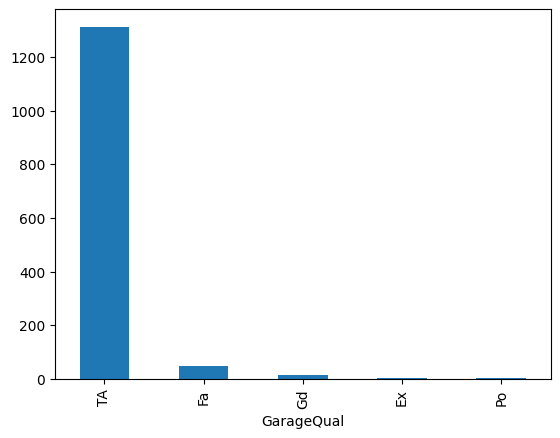

In [ ]:
df['GarageQual'].value_counts().plot(kind = 'bar')

In [ ]:
df['GarageQual'].mode()

,GarageQual
0,TA


In [ ]:
temp = df[df['GarageQual'] == 'TA']['SalePrice']

In [ ]:
df['GarageQual'].fillna('TA', inplace = True)

/tmp/ipykernel_4616/2652256314.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['GarageQual'].fillna('TA', inplace = True)


<Axes: xlabel='GarageQual'>

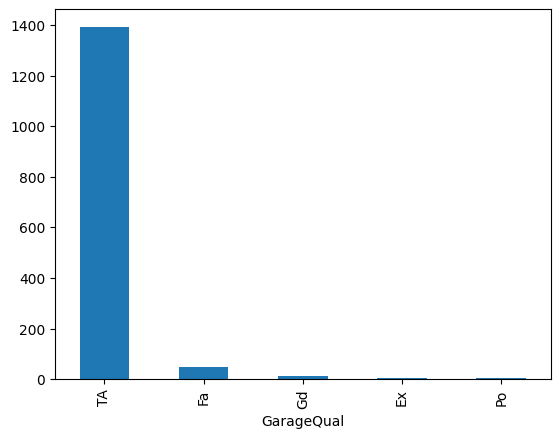

In [ ]:
df['GarageQual'].value_counts().plot(kind = 'bar')

<Axes: xlabel='FireplaceQu'>

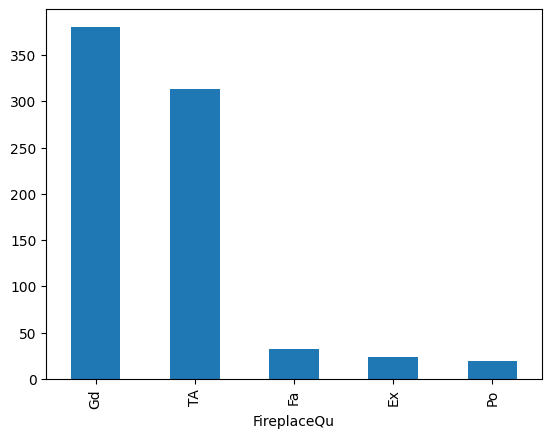

In [ ]:
df['FireplaceQu'].value_counts().plot(kind = 'bar')

In [ ]:
df['FireplaceQu'].mode()

,FireplaceQu
0,Gd


In [ ]:
temp = df[df['FireplaceQu'] == 'Gd']['SalePrice']

In [ ]:
df['FireplaceQu'].fillna('Gd', inplace = True)

/tmp/ipykernel_4616/1727683287.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['FireplaceQu'].fillna('Gd', inplace = True)


<Axes: xlabel='FireplaceQu'>

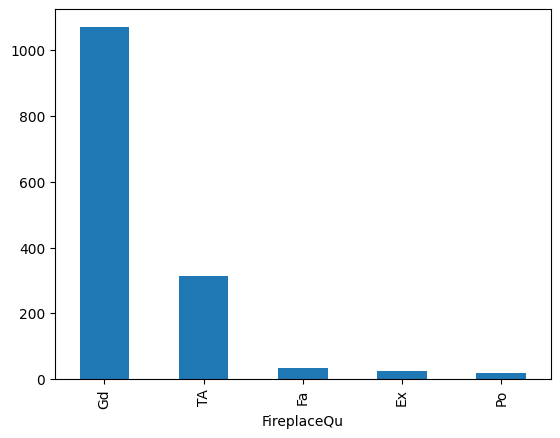

In [ ]:
df['FireplaceQu'].value_counts().plot(kind = 'bar')

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(df.drop('SalePrice', axis = 1), df['SalePrice'], test_size = 0.2, random_state = 0)

NameError: name 'df' is not defined

In [ ]:
imputer1 = SimpleImputer(strategy = 'most_frequent')

In [ ]:
x_train = imputer1.fit_transform(x_train)
x_test = imputer1.transform(x_test)

In [ ]:
imputer1.statistics_

array(['Gd', 'TA'], dtype=object)

In [ ]:
imputer2 = SimpleImputer(strategy = 'constant', fill_value = 'missing')

In [ ]:
x_train = imputer2.fit_transform(x_train)
x_test = imputer2.transform(x_test)

In [ ]:
imputer2.statistics_

array(['missing', 'missing'], dtype=object)

In [ ]:
df = pd.read_csv("/content/Titanic-Dataset.csv", usecols = ['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [ ]:
df.isnull().mean() * 100

,0
Survived,0.00000
Age,19.86532
Fare,0.00000


In [ ]:
x = df.drop('Survived', axis = 1)
y = df['Survived']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 2)

In [ ]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']
print(X_train.head())
print(X_test.head())

      Age     Fare  Age_imputed
30   40.0  27.7208         40.0
10    4.0  16.7000          4.0
873  47.0   9.0000         47.0
182   9.0  31.3875          9.0
876  20.0   9.8458         20.0
      Age     Fare  Age_imputed
707  42.0  26.2875         42.0
37   21.0   8.0500         21.0
615  24.0  65.0000         24.0
169  28.0  56.4958         28.0
68   17.0   7.9250         17.0


In [ ]:
X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
X_test['Age_imputed'][X_test['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_test['Age'].isnull().sum()).values

/tmp/ipykernel_1407/3090101260.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
/tmp/ipykernel_1407/3090101260.

In [ ]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([33. , 28. , 50. , 38. , 44. , 24. , 54. , 28.5, 38. , 30. , 22. ,
       34. , 22. , 24. , 22. , 45.5, 24. , 47. , 32.5, 54. , 60. , 12. ,
       15. , 33. ,  5. , 33. , 19. , 18. , 21. , 40.5, 33. , 54. , 35. ,
       29. , 41. , 22. , 24. , 40. , 14. , 53. , 25. ,  4. , 11. , 25. ,
       35. , 28. , 30. , 22. ,  7. , 20. , 42. , 15. , 34. , 71. , 39. ,
       18. , 22. , 18. ,  5. , 31. , 24. , 39. , 24. , 29. , 19. , 34. ,
       36. , 44. , 30. , 61. , 61. , 56. , 30. , 23. , 19. , 24. , 36. ,
       44. , 24. , 27. , 28. , 26. , 39. , 34. , 18. , 14. , 22. , 47. ,
       20. , 20. , 56. , 24. , 25. , 21. , 32. , 54. , 48. ,  3. ,  2. ,
       29. , 26. , 42. , 45. , 22. , 27. , 45. , 37. , 28. , 28. , 26. ,
       14. , 29. , 22. , 24. , 56. , 50. , 18. , 24. , 51. ,  2. , 28. ,
       32. , 29. , 30. ,  4. , 18. ,  7. , 36. , 30. , 24. , 19. , 16. ,
       40. , 58. , 21. , 16. , 27. , 30. , 30. , 30.5, 35. , 34. , 29. ,
       30. , 39. , 25. ,  6. , 27. ])